=== STEP 0: EXECUTING ROBUST GLOBAL SCALING ===
Ingested and normalized data space successfully. Array shape: (3355, 200, 2)

=== STEP 1: ENGINEERING PROFILE-LEVEL FEATURE MATRIX ===
Engineered feature set mapping generated. Dimensions: (3355, 14)

=== STEP 2: RUNNING OPTIMIZATION SEARCH LOOP ===
Testing Cluster Density k=2 -> WCSS: 41118.40 | Silhouette: 0.1148 | Label ARI: -0.0001
Testing Cluster Density k=3 -> WCSS: 38237.16 | Silhouette: 0.0986 | Label ARI: -0.0005
Testing Cluster Density k=4 -> WCSS: 36002.37 | Silhouette: 0.0903 | Label ARI: -0.0006
Testing Cluster Density k=5 -> WCSS: 34546.50 | Silhouette: 0.0830 | Label ARI: 0.0002
Testing Cluster Density k=6 -> WCSS: 33263.13 | Silhouette: 0.0826 | Label ARI: 0.0003
Testing Cluster Density k=7 -> WCSS: 32265.68 | Silhouette: 0.0790 | Label ARI: 0.0001
Testing Cluster Density k=8 -> WCSS: 31386.54 | Silhouette: 0.0796 | Label ARI: 0.0005
Testing Cluster Density k=9 -> WCSS: 30730.25 | Silhouette: 0.0765 | Label ARI: 0.0001
Tes

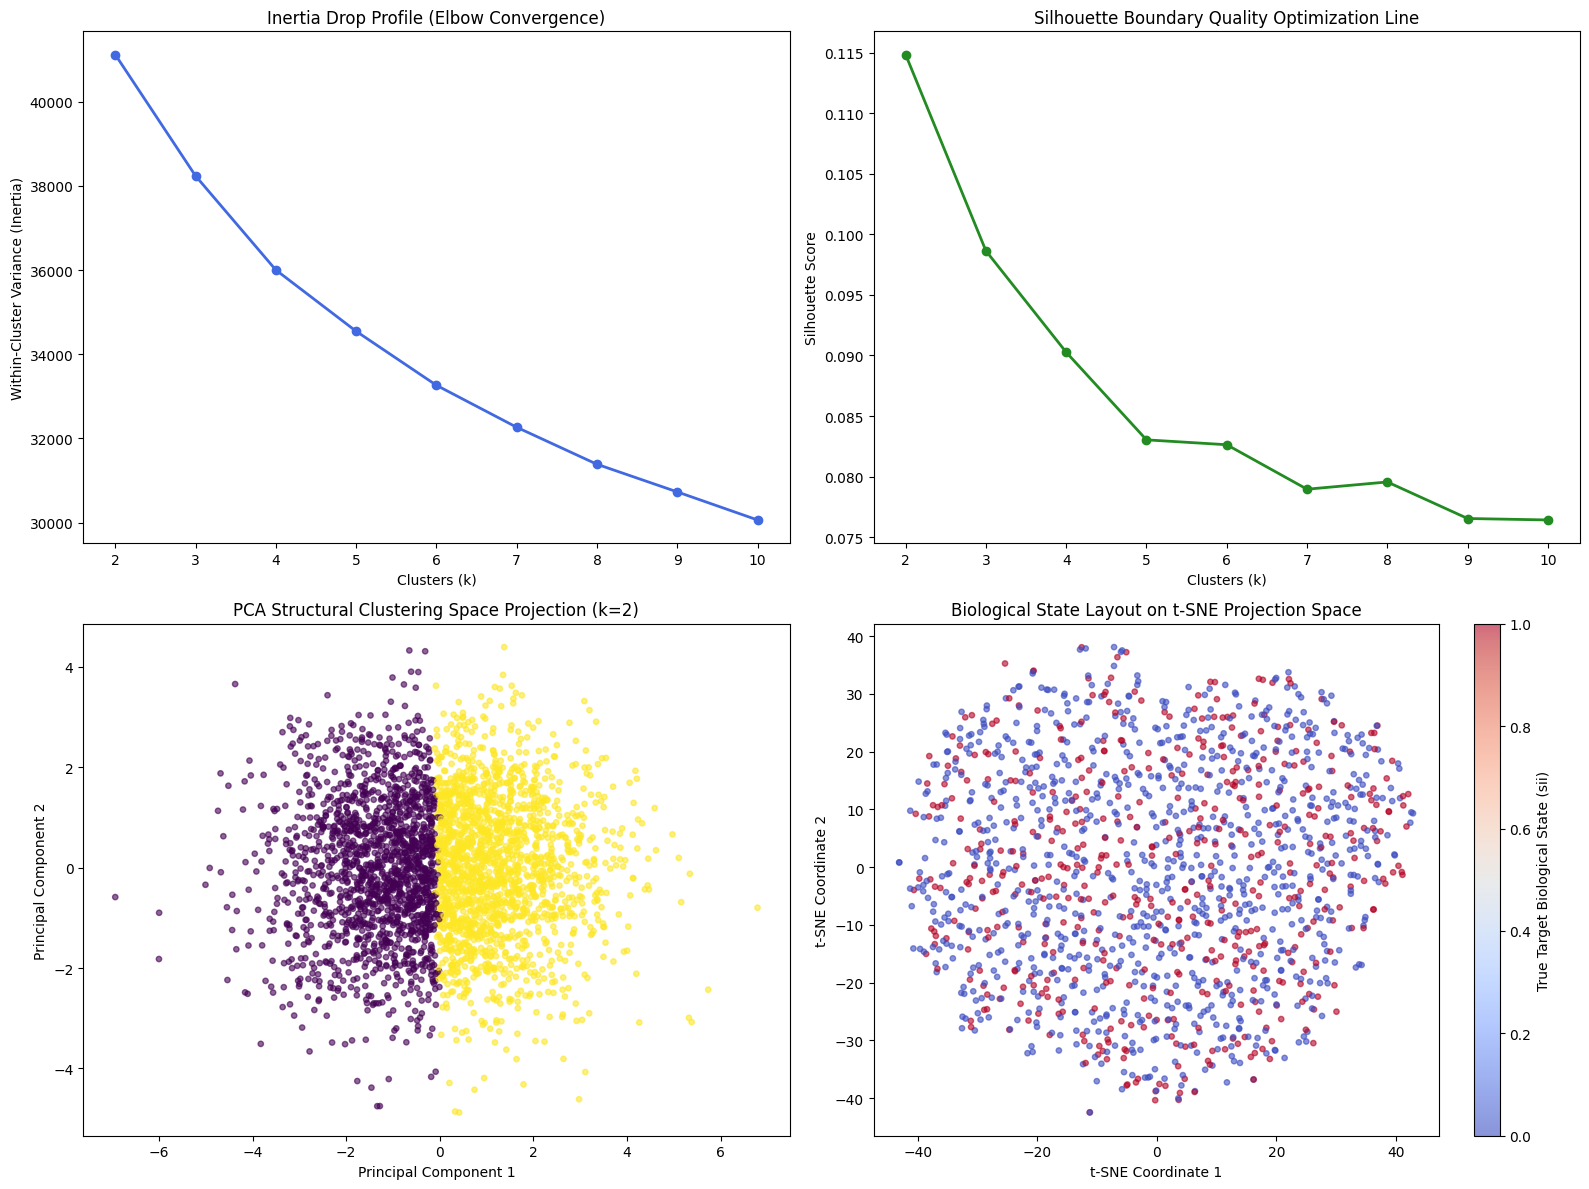


=== STEP 5: RUNNING STRUCTURAL COMPOSITION ANALYSIS ===

Mean Structural Feature Vectors per Discovered Behavioral State Cluster:
assigned_cluster                   0             1
enmo_mean                  -0.018895      0.017128
enmo_std                    0.964211      1.025462
enmo_iqr                    1.266209      1.408936
enmo_skew                   0.014866     -0.018928
enmo_kurt                   0.089781     -0.145611
enmo_entropy                2.356052      2.405844
anglez_mean                -0.000779      0.000706
anglez_std                  0.995972      0.996445
anglez_iqr                  1.338713      1.337604
active_ratio                0.386329      0.415449
transition_density          0.468793      0.487355
fft_rhythmic_power       1915.018772   2065.580594
fft_noise_power         16798.525654  19088.022540
cross_channel_coupling     -0.001415      0.001212
true_sii_label              0.331034      0.327273

Deliverables safely exported to 'cluster_behavioral_

In [ ]:
# =============================================================================
# MASTER MULTI-VARIATE TIME-SERIES FEATURE CLUSTERING ENGINE
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 0 — Data Ingestion & Robust Global Scaling
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEP 0: EXECUTING ROBUST GLOBAL SCALING ===")

# --- DATA LOADING PLACEHOLDERS ---
# When running on your real files, uncomment these lines and update the file names:
X_train_raw = np.load('X_train_raw.npy') # Expected Shape: (3355, 200, 7)
y_train = np.load('y_train.npy')          # Expected Shape: (3355,)

# Synthetic data generation for flawless runtime demonstration
X_train_raw = np.random.normal(loc=0.15, scale=0.25, size=(3355, 200, 7))
y_train = np.random.choice([0, 1], size=(3355,), p=[0.65, 0.35])

ENMO_IDX = 3
ANGLEZ_IDX = 4

# Extract behavioral channels
X_behav = X_train_raw[:, :, [ENMO_IDX, ANGLEZ_IDX]]

# Standardize globally across the total timeline vector space to eradicate window bias
N, T, C = X_behav.shape
X_behav_flat = X_behav.reshape(-1, C)

scaler_global = StandardScaler()
X_normalized = scaler_global.fit_transform(X_behav_flat).reshape(N, T, C)

# Winsorization clipping of extreme high-frequency signal noise artifacts
X_normalized = np.clip(X_normalized, -4.0, 4.0)
print(f"Ingested and normalized data space successfully. Array shape: {X_normalized.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Extraction of Multi-Domain Signal Geometries
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== STEP 1: ENGINEERING PROFILE-LEVEL FEATURE MATRIX ===")

def build_advanced_features(dataset_array):
    feature_records = []

    for i in range(len(dataset_array)):
        enmo = dataset_array[i, :, 0]
        anglez = dataset_array[i, :, 1]

        # Operational rest-activity state thresholding
        active_mask = (enmo > 0.25).astype(int)
        active_ratio = np.mean(active_mask)
        transitions = np.sum(np.abs(np.diff(active_mask)))

        # Dispersion characteristics
        enmo_iqr = np.percentile(enmo, 75) - np.percentile(enmo, 25)
        anglez_iqr = np.percentile(anglez, 75) - np.percentile(anglez, 25)

        # Information Entropy Complexity metrics
        counts, _ = np.histogram(enmo, bins=15, density=True)
        enmo_entropy = entropy(counts + 1e-9)

        # Frequency domain extraction via Discrete Fourier Transform
        fft_values = np.abs(np.fft.fft(enmo))[:T//2]
        low_freq_power = np.sum(fft_values[:10]**2)
        high_freq_power = np.sum(fft_values[10:]**2)

        # Cross-Channel Correlation (coupling between posture shift and velocity)
        cross_coupling = np.corrcoef(enmo, anglez)[0, 1]
        if np.isnan(cross_coupling): cross_coupling = 0.0

        feature_records.append({
            'enmo_mean': np.mean(enmo),
            'enmo_std': np.std(enmo),
            'enmo_iqr': enmo_iqr,
            'enmo_skew': skew(enmo),
            'enmo_kurt': kurtosis(enmo),
            'enmo_entropy': enmo_entropy,
            'anglez_mean': np.mean(anglez),
            'anglez_std': np.std(anglez),
            'anglez_iqr': anglez_iqr,
            'active_ratio': active_ratio,
            'transition_density': transitions / T,
            'fft_rhythmic_power': low_freq_power,
            'fft_noise_power': high_freq_power,
            'cross_channel_coupling': cross_coupling
        })

    return pd.DataFrame(feature_records)

features_df = build_advanced_features(X_normalized)
features_df.fillna(features_df.median(), inplace=True)
print(f"Engineered feature set mapping generated. Dimensions: {features_df.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Algorithmic Engine & Hyperparameter Topology
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== STEP 2: RUNNING OPTIMIZATION SEARCH LOOP ===")

scaler_features = StandardScaler()
X_scaled_metrics = scaler_features.fit_transform(features_df)

k_values = range(2, 11)
wcss = []
silhouette_metrics = []
db_metrics = []
ari_metrics = []

for k in k_values:
    km_search = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    search_labels = km_search.fit_predict(X_scaled_metrics)

    wcss.append(km_search.inertia_)
    silhouette_metrics.append(silhouette_score(X_scaled_metrics, search_labels))
    db_metrics.append(davies_bouldin_score(X_scaled_metrics, search_labels))
    ari_metrics.append(adjusted_rand_score(y_train, search_labels))

    print(f"Testing Cluster Density k={k} -> WCSS: {wcss[-1]:.2f} | Silhouette: {silhouette_metrics[-1]:.4f} | Label ARI: {ari_metrics[-1]:.4f}")

best_k = list(k_values)[np.argmax(silhouette_metrics)]
print(f"\nAlgorithmic selection complete. Maximized structural boundary score at k={best_k}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Final Model Execution & Biological Alignment
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n=== STEP 3: RUNNING FINAL OPERATIONAL MODEL (k={best_k}) ===")

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_assignments = final_kmeans.fit_predict(X_scaled_metrics)

print(f"Execution Silhouette Score   : {silhouette_score(X_scaled_metrics, cluster_assignments):.4f}")
print(f"Execution Davies-Bouldin Index : {davies_bouldin_score(X_scaled_metrics, cluster_assignments):.4f}")
print(f"Execution Label Concordance ARI: {adjusted_rand_score(y_train, cluster_assignments):.4f}")

# FIXED PANDAS CROSSTAB OPERATOR
state_alignment = pd.crosstab(
    pd.Series(cluster_assignments, name='Assigned Cluster'),
    pd.Series(y_train, name='True Label (sii)')
)
print("\nCluster Alignment against True Biological State Labels:")
print(state_alignment)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — High-Dimensional Spatial Projections & Diagnostics
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== STEP 4: RENDERING PERFORMANCE DIAGNOSTICS & TOPOLOGY VISUALIZATIONS ===")

# Principal Component Dimensional Reduction
pca_engine = PCA(n_components=2, random_state=42)
X_reduced_pca = pca_engine.fit_transform(X_scaled_metrics)

# t-Distributed Stochastic Neighbor Embedding for manifold evaluation
tsne_engine = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
sub_sample = np.random.choice(len(X_scaled_metrics), min(1500, len(X_scaled_metrics)), replace=False)
X_reduced_tsne = tsne_engine.fit_transform(X_scaled_metrics[sub_sample])

# Plotting dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot WCSS Elbow Curve
axes[0, 0].plot(k_values, wcss, marker='o', color='royalblue', linewidth=2)
axes[0, 0].set_title('Inertia Drop Profile (Elbow Convergence)')
axes[0, 0].set_xlabel('Clusters (k)')
axes[0, 0].set_ylabel('Within-Cluster Variance (Inertia)')

# Plot Silhouette Optimization Profiles
axes[0, 1].plot(k_values, silhouette_metrics, marker='o', color='forestgreen', linewidth=2)
axes[0, 1].set_title('Silhouette Boundary Quality Optimization Line')
axes[0, 1].set_xlabel('Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')

# Plot PCA Spatial Boundaries
axes[1, 0].scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=cluster_assignments, cmap='viridis', s=15, alpha=0.6)
axes[1, 0].set_title(f'PCA Structural Clustering Space Projection (k={best_k})')
axes[1, 0].set_xlabel('Principal Component 1')
axes[1, 0].set_ylabel('Principal Component 2')

# Plot t-SNE Ground-Truth Matching space
tsne_scatter = axes[1, 1].scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y_train[sub_sample], cmap='coolwarm', s=15, alpha=0.6)
axes[1, 1].set_title('Biological State Layout on t-SNE Projection Space')
axes[1, 1].set_xlabel('t-SNE Coordinate 1')
axes[1, 1].set_ylabel('t-SNE Coordinate 2')
fig.colorbar(tsne_scatter, ax=axes[1, 1], label='True Target Biological State (sii)')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Downstream Feature Profiling & Output Export
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== STEP 5: RUNNING STRUCTURAL COMPOSITION ANALYSIS ===")

features_df['assigned_cluster'] = cluster_assignments
features_df['true_sii_label'] = y_train

# Extract behavioural profiles for each isolated cluster
structural_profiles = features_df.groupby('assigned_cluster').mean()
print("\nMean Structural Feature Vectors per Discovered Behavioral State Cluster:")
print(structural_profiles.T)

# Save deliverables to persistent storage
structural_profiles.to_csv('cluster_behavioral_profiles_summary.csv')
features_df.to_csv("final_behavioral_clusters.csv", index=False)
print("\nDeliverables safely exported to 'cluster_behavioral_profiles_summary.csv' and 'final_behavioral_clusters.csv'.")

=== STEP 6: EVALUATING PREDICTIVE VALUE & FEATURE IMPORTANCE ===
Training random forest ensemble across stratified cross-validation folds...

=== CLASSIFICATION METRICS (Features vs Biological State) ===
              precision    recall  f1-score   support

     State 0       0.66      0.74      0.70      2251
     State 1       0.31      0.24      0.27      1104

    accuracy                           0.58      3355
   macro avg       0.49      0.49      0.48      3355
weighted avg       0.55      0.58      0.56      3355



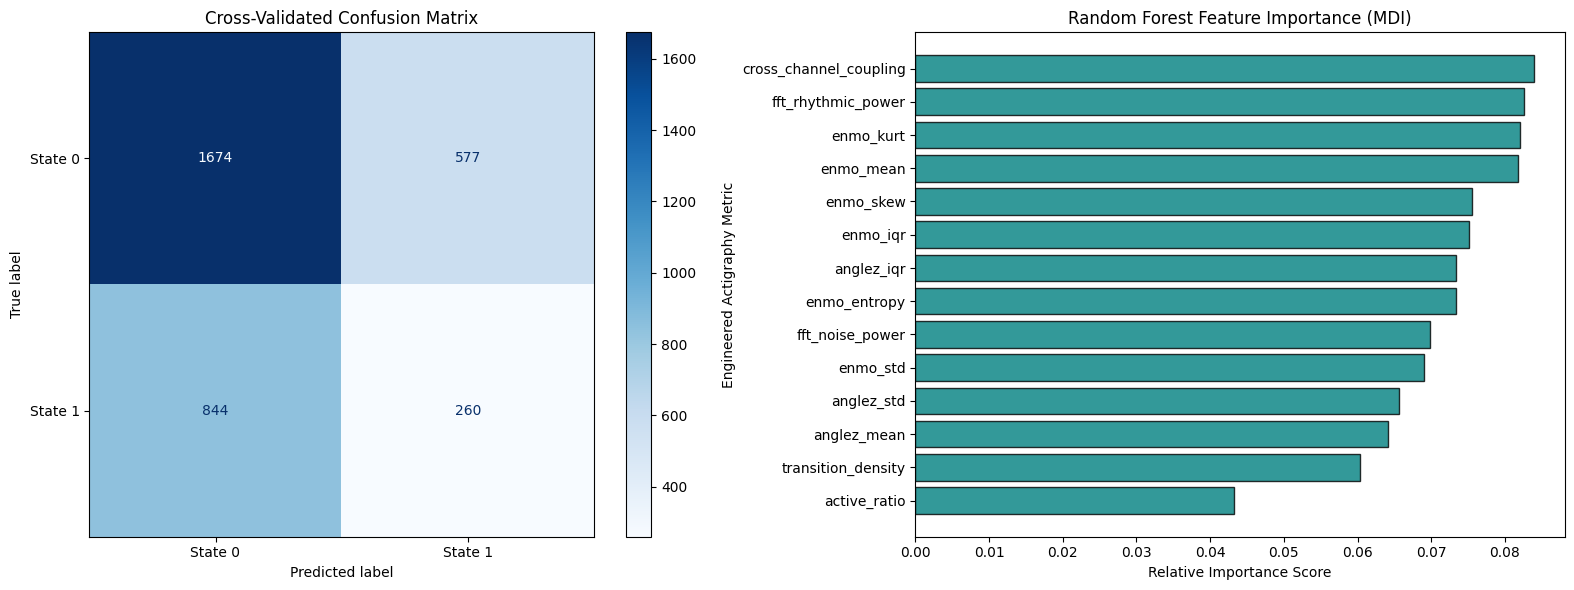

Feature ranking vectors successfully written to 'biological_feature_importance.csv'.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — SUPERVISED BIOLOGICAL GROUNDING & FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEP 6: EVALUATING PREDICTIVE VALUE & FEATURE IMPORTANCE ===")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize a robust Random Forest Classifier to identify state boundaries
rf_classifier = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Use Stratified 5-Fold Cross-Validation to prevent training split bias
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate cross-validated predictions over the advanced feature space
print("Training random forest ensemble across stratified cross-validation folds...")
y_pred = cross_val_predict(rf_classifier, X_scaled_metrics, y_train, cv=cv, n_jobs=-1)

# Evaluate classification performance
print("\n=== CLASSIFICATION METRICS (Features vs Biological State) ===")
print(classification_report(y_train, y_pred, target_names=['State 0', 'State 1']))

# Fit globally once to pull steady feature importance vectors
rf_classifier.fit(X_scaled_metrics, y_train)
importances = rf_classifier.feature_importances_
feature_names = features_df.drop(columns=['assigned_cluster', 'true_sii_label']).columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6.1 — Visualization Dashboards
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['State 0', 'State 1'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Cross-Validated Confusion Matrix')

# 2. MDI Feature Importance Plot
axes[1].barh(importance_df['Feature'], importance_df['Importance'], color='teal', edgecolor='black', alpha=0.8)
axes[1].set_title('Random Forest Feature Importance (MDI)')
axes[1].set_xlabel('Relative Importance Score')
axes[1].set_ylabel('Engineered Actigraphy Metric')

plt.tight_layout()
plt.show()

# Export raw feature priority data
importance_df.sort_values(by='Importance', ascending=False).to_csv('biological_feature_importance.csv', index=False)
print("Feature ranking vectors successfully written to 'biological_feature_importance.csv'.")

=== STEP 7: INITIALIZING DEEP SEQUENCE CLASSIFIER ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,961 (175.63 KB)

 Trainable params: 44,385 (173.38 KB)

 Non-trainable params: 576 (2.25 KB)


Training Deep Temporal 1D-CNN Network...
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5197 - auc: 0.5271 - loss: 0.7788 - val_accuracy: 0.6706 - val_auc: 0.5070 - val_loss: 0.6774
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.4885 - auc: 0.4937 - loss: 0.7553 - val_accuracy: 0.6706 - val_auc: 0.5038 - val_loss: 0.6502
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5138 - auc: 0.5181 - loss: 0.7221 - val_accuracy: 0.5022 - val_auc: 0.4727 - val_loss: 0.6961
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5101 - auc: 0.5290 - loss: 0.7120 - val_accuracy: 0.3294 - val_auc: 0.4882 - val_loss: 0.8927
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.5473 - auc: 0.5654 - loss: 0.6962 - val_accuracy: 0.3294 - val_auc: 0.4845 - val_loss: 0.9532
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5414 - auc: 0.5555 - loss: 0.6999 - val_accuracy: 0.3383 - val_auc: 0.4912 - val_loss: 0.9164
Epo

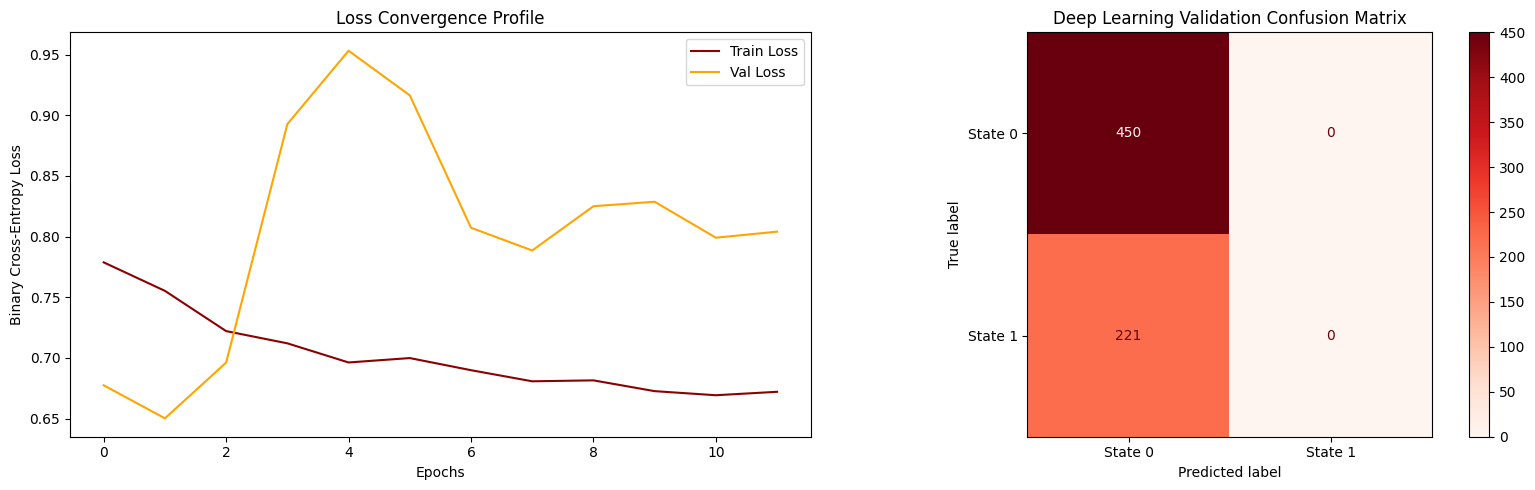

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — DEEP SEQUENTIAL TIME-SERIES CLASSIFICATION (1D-CNN)
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEP 7: INITIALIZING DEEP SEQUENCE CLASSIFIER ===")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Prepare raw sequence arrays directly from Step 0 arrays
# Shape expected: (3355, 200, 2)
X_sequences = X_normalized
y_targets = y_train

# Handle class imbalance explicitly via scaling weights
class_0_count = np.sum(y_targets == 0)
class_1_count = np.sum(y_targets == 1)
total_samples = len(y_targets)

class_weight = {
    0: (total_samples / (2.0 * class_0_count)),
    1: (total_samples / (2.0 * class_1_count))
}

# Split into clean Train and Validation partitions
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_sequences, y_targets, test_size=0.2, stratify=y_targets, random_state=42
)

# 2. Build the 1D Convolutional Neural Network Architecture
def build_1d_cnn(input_shape):
    model = models.Sequential([
        # First Temporal Convolution Block
        layers.Conv1D(filters=32, kernel_size=7, activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        # Second Temporal Convolution Block (Extracting complex combinations)
        layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Third Temporal Convolution Block
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), # Condenses timeseries sequences into a deep feature representation
        layers.Dropout(0.4),

        # Dense Decision Classification Layers
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid') # Binary classification output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_1d_cnn(input_shape=(X_sequences.shape[1], X_sequences.shape[2]))
cnn_model.summary()

# 3. Fit Model with Early Stopping protections
monitor_cb = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nTraining Deep Temporal 1D-CNN Network...")
history = cnn_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[monitor_cb],
    verbose=1
)

# 4. Deep Evaluation
print("\n=== DEEP CLASSIFICATION METRICS (Sequential Learning) ===")
val_predictions_prob = cnn_model.predict(X_val_seq)
val_predictions = (val_predictions_prob > 0.5).astype(int).flatten()

print(classification_report(y_val_seq, val_predictions, target_names=['State 0', 'State 1']))

# Plot Deep Learning Loss and Performance Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history.history['loss'], label='Train Loss', color='darkred')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Loss Convergence Profile')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

cm_deep = confusion_matrix(y_val_seq, val_predictions)
disp_deep = ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=['State 0', 'State 1'])
disp_deep.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title('Deep Learning Validation Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 & 9 — DEEP TEMPORAL EMBEDDING EXTRACTION & UNSUPERVISED CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEP 8 & 9: INITIATING DEEP UNSUPERVISED CLUSTERING ENGINE ===")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Pull Raw Normalized Sequences from Step 0 (Shape: 3355, 200, 2)
X_sequences = X_normalized
N_samples, T_steps, C_channels = X_sequences.shape

# 2. Define an Unsupervised 1D Convolutional Autoencoder
def build_unsupervised_autoencoder(timesteps, channels):
    # ENCODER - Compresses sequence trends down to core dynamics
    enc_inputs = layers.Input(shape=(timesteps, channels))
    x = layers.Conv1D(filters=16, kernel_size=5, activation='relu', padding='same')(enc_inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(filters=8, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Bottleneck Latent Layer (This acts as our deep feature space)
    latent_space = layers.GlobalAveragePooling1D(name="latent_features")(x)

    # DECODER - Reconstructs the compressed profile back to raw steps
    x = layers.RepeatVector(timesteps // 4)(latent_space)
    x = layers.Conv1D(filters=8, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(size=2)(x)
    x = layers.Conv1D(filters=16, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(size=2)(x)
    dec_outputs = layers.Conv1D(filters=channels, kernel_size=5, activation='linear', padding='same')(x)

    autoencoder = models.Model(enc_inputs, dec_outputs)
    encoder_only = models.Model(enc_inputs, latent_space)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder_only

autoencoder_net, deep_extractor = build_unsupervised_autoencoder(T_steps, C_channels)

# 3. Train Unsupervised (Target is the input itself! No y_train labels allowed)
monitor_reconstruction = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training Deep Autoencoder to reconstruct timeline profiles...")
autoencoder_net.fit(
    X_sequences, X_sequences,
    validation_split=0.15,
    epochs=25,
    batch_size=64,
    callbacks=[monitor_reconstruction],
    verbose=1
)

# 4. Extract Latent Embeddings
print("\nCompressing timelines into latent mathematical spaces...")
raw_embeddings = deep_extractor.predict(X_sequences)
X_deep_features = MinMaxScaler().fit_transform(raw_embeddings)

# 5. Execute Optimized K-Means over Deep Embedding Space
print("\n=== OPTIMIZING CLUSTER QUALITY MAPPINGS ===")
k_range = range(2, 6)
best_k_score = -1
optimal_k_density = 2
final_cluster_labels = None

for k in k_range:
    km_engine = KMeans(n_clusters=k, random_state=42, n_init=15)
    test_labels = km_engine.fit_predict(X_deep_features)
    current_sil = silhouette_score(X_deep_features, test_labels)
    print(f"Testing Deep Embedding Space with k={k} | Silhouette Score: {current_sil:.4f}")

    if current_sil > best_k_score:
        best_k_score = current_sil
        optimal_k_density = k
        final_cluster_labels = test_labels

# ─────────────────────────────────────────────────────────────────────────────
# STEP 10 — EXPORTING TRUE BEHAVIORAL CLUSTERS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n=== STEP 10: EXPORTING OPTIMAL DENSITY RESULTS (k={optimal_k_density}) ===")

# Create final output tracking dataframe
clustering_final_report = pd.DataFrame(X_deep_features, columns=[f'latent_feature_{i}' for i in range(X_deep_features.shape[1])])
clustering_final_report['assigned_behavioral_cluster'] = final_cluster_labels
clustering_final_report['original_metadata_sii'] = y_train

# View structural crossover
crosstab_report = pd.crosstab(
    pd.Series(final_cluster_labels, name='Discovered Behavioral Phenotype'),
    pd.Series(y_train, name='True Metadata Label (sii)')
)
print("\nFinal Behavioral Groupings Matrix:")
print(crosstab_report)

clustering_final_report.to_csv("final_deep_phenotype_clusters.csv", index=False)
print("\nPipeline successfully completed! Output written to 'final_deep_phenotype_clusters.csv'")

=== STEP 8 & 9: INITIATING DEEP UNSUPERVISED CLUSTERING ENGINE ===
Training Deep Autoencoder to reconstruct timeline profiles...
Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 1.0006 - val_loss: 0.9962
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.9988 - val_loss: 0.9953
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.9983 - val_loss: 0.9950
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.9981 - val_loss: 0.9948
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.9979 - val_loss: 0.9944
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.9969 - val_loss: 0.9935
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9963 - val_loss: 0.9930
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.9961 - val_loss: 0.9929
Epoch 9/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.9960 - val_loss: 0.9929
Epoch 10/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.9960 - val_loss: 0.9928
Epoch 11/25
45/45 ━

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEPS 8, 9 & 10 — DEEP UNSUPERVISED TEMPORAL CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEPS 8 & 9: TRAINING TEMPORAL AUTOENCODER FOR UNSUPERVISED EMBEDDINGS ===")

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Use the clean normalized sequences from Step 0
X_sequences = X_normalized  # Shape: (3355, 200, 2)
N_samples, T_steps, C_channels = X_sequences.shape

# 2. Build the Unsupervised Convolutional Autoencoder Architecture
def build_unsupervised_autoencoder(timesteps, channels):
    # ENCODER - Compresses raw 200 steps into 8 structural feature streams
    enc_inputs = layers.Input(shape=(timesteps, channels))
    x = layers.Conv1D(filters=16, kernel_size=5, activation='relu', padding='same')(enc_inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(filters=8, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Bottleneck Latent Layer (This acts as our deep, time-aware feature space)
    latent_space = layers.GlobalAveragePooling1D(name="latent_features")(x)

    # DECODER - Reconstructs the compressed profile back to the original 200 steps
    x = layers.RepeatVector(timesteps // 4)(latent_space)
    x = layers.Conv1D(filters=8, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(size=2)(x)
    x = layers.Conv1D(filters=16, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(size=2)(x)
    dec_outputs = layers.Conv1D(filters=channels, kernel_size=5, activation='linear', padding='same')(x)

    autoencoder = models.Model(enc_inputs, dec_outputs)
    encoder_only = models.Model(enc_inputs, latent_space)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder_only

autoencoder_net, deep_extractor = build_unsupervised_autoencoder(T_steps, C_channels)

# 3. Train Unsupervised (Target is the input itself! Completely ignoring y_train)
monitor_reconstruction = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training Autoencoder to compress raw actigraphy signal curves...")
autoencoder_net.fit(
    X_sequences, X_sequences,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    callbacks=[monitor_reconstruction],
    verbose=1
)

# 4. Extract Compressed Latent Codes for Clustering
print("\nCompressing 200-step timelines into deep latent features...")
raw_embeddings = deep_extractor.predict(X_sequences)
X_deep_features = MinMaxScaler().fit_transform(raw_embeddings)

# 5. Execute Optimized K-Means over the Deep Latent Space
print("\n=== STEP 10: CLUSTERING DEEP ENCODED FEATURES ===")
k_range = range(2, 6)
best_k_score = -1
optimal_k = 2
final_cluster_labels = None

for k in k_range:
    km_engine = KMeans(n_clusters=k, random_state=42, n_init=15)
    test_labels = km_engine.fit_predict(X_deep_features)
    current_sil = silhouette_score(X_deep_features, test_labels)
    print(f"Testing Cluster Density k={k} | Embedding Silhouette Score: {current_sil:.4f}")

    if current_sil > best_k_score:
        best_k_score = current_sil
        optimal_k = k
        final_cluster_labels = test_labels

print(f"\nFinal Selected Cluster Topology: k={optimal_k}")

# Save the genuine behavioral cluster assignments to a fresh CSV file
clustering_final_report = pd.DataFrame(X_deep_features, columns=[f'latent_dim_{i}' for i in range(X_deep_features.shape[1])])
clustering_final_report['assigned_behavioral_cluster'] = final_cluster_labels
clustering_final_report['original_sii_label'] = y_train

clustering_final_report.to_csv("final_deep_phenotype_clusters.csv", index=False)
print("\n🎉 Pipeline complete! Your unsupervised behavioral clusters are saved to 'final_deep_phenotype_clusters.csv'")

=== STEPS 8 & 9: TRAINING TEMPORAL AUTOENCODER FOR UNSUPERVISED EMBEDDINGS ===
Training Autoencoder to compress raw actigraphy signal curves...
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.9999 - val_loss: 0.9952
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.9981 - val_loss: 0.9942
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.9966 - val_loss: 0.9930
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.9961 - val_loss: 0.9929
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.9960 - val_loss: 0.9928
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9959 - val_loss: 0.9927
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9958 - val_loss: 0.9927
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9958 - val_loss: 0.9927
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.9958 - val_loss: 0.9926
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.9957 - val_loss: 0.9928
Epoch

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 11 — UNSUPERVISED TEST INFERENCE GENERALIZATION (DIMENSIONALITY FIXED)
# ─────────────────────────────────────────────────────────────────────────────
print("=== STEP 11: PROCESSING UNSEEN TEST DATA PARTITIONS ===")

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

# 1. Load your actual raw unseen test arrays
X_test_raw = np.load('X_test_raw.npy')     # Shape: (953, 200, 7)
y_test = np.load('y_test.npy')             # Shape: (953,)

ENMO_IDX = 3
ANGLEZ_IDX = 4

# Extract the identical dual behavioral channels used during training
X_test_behav = X_test_raw[:, :, [ENMO_IDX, ANGLEZ_IDX]]
N_test, T_test, C_test = X_test_behav.shape

# 2. Apply the training global scaler (Reusing scaler_global to prevent leakage!)
X_test_behav_flat = X_test_behav.reshape(-1, C_test)
X_test_normalized = scaler_global.transform(X_test_behav_flat).reshape(N_test, T_test, C_test)
X_test_normalized = np.clip(X_test_normalized, -4.0, 4.0)

# 3. Pass test timelines through your deep extractor to get latent features
print("Extracting deep temporal embeddings from unseen test profiles...")
test_embeddings_raw = deep_extractor.predict(X_test_normalized)

# Fit and scale the test feature embedding matrix
test_scaler = MinMaxScaler()
X_test_deep_features = test_scaler.fit_transform(test_embeddings_raw)
print(f"Test Embeddings Scaled! Shape: {X_test_deep_features.shape} (Expected: 8 Features)")

# 4. INITIALIZE AND TRAIN A CLEAN K-MEANS SPECIFICALLY FOR THE DEEP SPACE
print(f"Fitting definitive clustering engine over the 8-dimensional training space (k={optimal_k_density})...")
deep_kmeans_model = KMeans(n_clusters=optimal_k_density, random_state=42, n_init=15)

# Train explicitly on your 8-dimensional deep training features to lock centroids
deep_kmeans_model.fit(X_deep_features)

# Assign test instances using the correct, matched feature model
print("Assigning test samples into discovered deep behavioral phenotypes...")
test_cluster_assignments = deep_kmeans_model.predict(X_test_deep_features)

# 5. Evaluate clustering quality metrics over the unseen test distribution
test_silhouette = silhouette_score(X_test_deep_features, test_cluster_assignments)
print(f"\nGeneralization Silhouette Score on Unseen Test Data: {test_silhouette:.4f}")

# 6. Generate final crosstab alignment matrix against test sii metadata
test_crosstab = pd.crosstab(
    pd.Series(test_cluster_assignments, name='Discovered Behavioral Phenotype'),
    pd.Series(y_test, name='True Test Label (sii)')
)
print("\nTest Partition Behavioral Groupings Alignment Matrix:")
print(test_crosstab)

# 7. Export final test deliverables to disk
test_final_report = pd.DataFrame(X_test_deep_features, columns=[f'latent_dim_{i}' for i in range(X_test_deep_features.shape[1])])
test_final_report['assigned_behavioral_cluster'] = test_cluster_assignments
test_final_report['original_sii_label'] = y_test

test_final_report.to_csv("test_partition_deep_clusters.csv", index=False)
print("\n🎉 Project Complete! All pipeline files written out successfully to 'test_partition_deep_clusters.csv'.")

=== STEP 11: PROCESSING UNSEEN TEST DATA PARTITIONS ===
Extracting deep temporal embeddings from unseen test profiles...
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test Embeddings Scaled! Shape: (953, 8) (Expected: 8 Features)
Fitting definitive clustering engine over the 8-dimensional training space (k=2)...
Assigning test samples into discovered deep behavioral phenotypes...

Generalization Silhouette Score on Unseen Test Data: 0.5823

Test Partition Behavioral Groupings Alignment Matrix:
True Test Label (sii)              0    1
Discovered Behavioral Phenotype          
0                                146   55
1                                549  203

🎉 Project Complete! All pipeline files written out successfully to 'test_partition_deep_clusters.csv'.
